In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import optimizers
from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense, Activation, Input
from tensorflow.keras.models import Sequential, Model
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import backend as K
K.clear_session()
import tensorflow as tf
import random
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
import glob, os
import pandas as pd
datasets = 14#int(input("¿Cuántos datasets desea cargar? "))
seleccion = 14#random.sample(range(1, 13), datasets)
#print(len(seleccion))
#for dtst in range(1, 14):

data = 'C:\\Users\\User\\Desktop\\Experimental FSS Datasets\\Datasets\\Synthetic_Experimental' 
#'C:\\Users\\Lab Optica\\Desktop\\Isaac Huertas\\Datasets\\'+str(dtst)#+str(seleccion[dtst])
os.chdir(data)

# if dtst < 2:
#     files = []     # "files" es una lista que va a contener cada uno de los nombres (str) de las imagenes
#     for file in glob.glob("*.tiff"):
#         files.append(file)

#     print('test dataset #', seleccion[dtst])
#     num_datos = 1752*2
#     dim = 224 #dimension (dim, dim) Ipunt of VGG16 = 224x224
#     X_test_ = np.zeros(shape=[num_datos, dim, dim, 3], dtype=np.uint8)    # Imagenes
#     y_test_ = np.zeros(shape=[num_datos, 1], dtype=np.float32)              # Temperaturas
#     j=0

#     for i in range(0,1752):
#         ini = files[i].find('mm_')+3
#         fin = files[i].find('C')

#             y_test_[j] = float(files[i][ini:fin])    # temperatura extraída del str
#             X_test_[j,:,:,:] = np.asarray(load_img(files[i],
#                                             color_mode='rgb', target_size=(dim, dim, 3)))
#             j+=1
# else:
files = []     # "files" es una lista que va a contener cada uno de los nombres (str) de las imagenes
for file in glob.glob("*.tiff"):
    files.append(file)

#print('dataset #', dtst) #seleccion[dtst])
num_datos = 1752
dim = 224 #dimension (dim, dim) Ipunt of VGG16 = 224x224
X = np.zeros(shape=[num_datos, dim, dim, 3], dtype=np.uint8)    # Imagenes
y = np.zeros(shape=[num_datos, 1], dtype=np.float32)              # Temperaturas
j=0

for i in range(0,1752):
    ini = files[i].find('mm_')+3
    fin = files[i].find('C')

    y[j] = float(files[i][ini:fin])    # temperatura extraída del str
    X[j,:,:,:] = np.asarray(load_img(files[i],
                                    color_mode='rgb', target_size=(dim, dim, 3)))
    j+=1    
data = 'C:\\Users\\User\\Desktop\\Experimental FSS Datasets\\Datasets\\14_100C'
os.chdir(data)
files = []     # "files" es una lista que va a contener cada uno de los nombres (str) de las imagenes
for file in glob.glob("*.tiff"):
    files.append(file)

print('test dataset #', 14)
num_datos = 756
dim = 224 #dimension (dim, dim) Ipunt of VGG16 = 224x224
X_test_ = np.zeros(shape=[num_datos, dim, dim, 3], dtype=np.uint8)    # Imagenes
y_test_ = np.zeros(shape=[num_datos, 1], dtype=np.float32)              # Temperaturas
j=0

for i in range(0,num_datos):
    ini = files[i].find('mm_')+3
    fin = files[i].find('C')

    y_test_[j] = float(files[i][ini:fin])    # temperatura extraída del str
    X_test_[j,:,:,:] = np.asarray(load_img(files[i],
                                    color_mode='rgb', target_size=(dim, dim, 3)))
    j+=1

test dataset # 14


In [28]:
num_muestras = len(X)

# Generar un índice aleatorio para desordenar los datos manteniendo la relación
indice_desordenado = np.random.permutation(num_muestras)

# Aplicar el índice desordenado a ambos arreglos
X_desordenadas = X[indice_desordenado]
y_desordenadas = y[indice_desordenado]

# Guardar los datos desordenados en nuevos archivos .npy
# np.save('X_desordenadas.npy', imagenes_desordenadas)
# np.save('y_desordenadas.npy', clases_desordenadas)

print(X_desordenadas.shape)
print(y_desordenadas.shape)

(1752, 224, 224, 3)
(1752, 1)


In [29]:
# Divido sets de train, validación y test
from sklearn.model_selection import train_test_split
X_train_, X_val_, y_train_, y_val_ = train_test_split(X_desordenadas, y_desordenadas, test_size=0.2, random_state=1)

In [30]:
print(X_test_.shape)
print(X_train_.shape) 

(756, 224, 224, 3)
(1401, 224, 224, 3)


In [31]:
np.transpose(y_test_[:5])

# Normalizamos X
X_train = X_train_/255
X_val = X_val_/255
X_test = X_test_/255
y_train = y_train_
y_val = y_val_
y_test = y_test_

In [32]:
# X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
# X_val   = tf.convert_to_tensor(X_val, dtype=tf.float32)
# X_test  = tf.convert_to_tensor(X_test, dtype=tf.float32)

# y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
# y_val   = tf.convert_to_tensor(y_val, dtype=tf.float32)
# y_test  = tf.convert_to_tensor(y_test, dtype=tf.float32)

In [33]:
# def augment_data(image, temperature):
#     # Rotación aleatoria en un ángulo de 360 grados
#     image = tf.keras.preprocessing.image.random_rotation(image, 360, row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest')

#     # Cambio de escala aleatorio de 0.95 a 1.05 
#     image = tf.keras.preprocessing.image.random_zoom(image, (0.95, 1.05), row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest')

#     # Traslación aleatoria en horizontal y vertical 
#     image = tf.keras.preprocessing.image.random_shift(image, 0.008, 0.008, row_axis=0, col_axis=1, channel_axis=2, fill_mode='nearest')
    
#     # Ajustar el contraste de la imagen
#     contrast_factor = np.random.uniform(0.8, 1.2)
#     image = tf.image.adjust_contrast(image, contrast_factor=contrast_factor)
#     # image = tf.clip_by_value(image, 0.0, 1.0)

#     # Agregar ruido gaussiano a la imagen
#     stddev_var = np.random.uniform(0.0, 0.05) # Desviación estándar aleatoria entre 0.0 y 0.05
#     noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=stddev_var, dtype=tf.float64)
#     image = tf.clip_by_value(image + noise, 0.0, 1.0)

#     return image, temperature

In [34]:
# %%time
# aum_por_img = 5 # número de veces que se aumenta cada imagen (más la imagen misma)
# num_datos = (aum_por_img+1)*len(X_train)
# X_aum = np.zeros(shape=[num_datos, 224, 224, 3], dtype=np.float32)    # Imagenes
# y_aum = np.zeros(shape=[num_datos, 1])                            # Temperaturas

# for i in range(aum_por_img+1):
#     for j in range(len(X_train)):
#         index = i*len(X_train)+j
#         # print(index)
#         X_aum[index,:,:,0:1], y_aum[index] = augment_data(X_train[j,:,:,0:1], y_train[j])

In [35]:
X_train.shape

(1401, 224, 224, 3)

In [36]:
#X_aum.shape

In [37]:
# https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV3Large
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D

In [38]:
# image_input = Input(shape=(224, 224, 3)) Esto es igual que decir base_model.input, porque se lo entramoe en 'input_shape'
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [39]:
def MNet_reg(num):
    # Agregar una capa de aplanamiento y dos capas densas para la regresión
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation="relu")(x)
    x = Dense(1024, activation="relu")(x)    
    x = Dense(1024, activation="relu")(x)
    x = Dropout(0.1)(x)

    output = Dense(1, activation="linear")(x)

    # Crear un modelo de TensorFlow que incluya la base de la red y las nuevas capas
    model = Model(inputs=base_model.input, outputs=output)

    model.trainable = True
    for layer in model.layers[:-num]:
        layer.trainable = False

    return model

In [40]:
def plot_epochs(history, li, ls):    # li -> limite inferior, ls -> limite superior en y!!!
    plt.figure()
    plt.ylim([li, ls])
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.plot(history.history['loss'],'bo')
    plt.plot(history.history['val_loss'],'r')

    plt.legend(['Pérdida de entrenamiento', 'Pérdida de validación'], loc='upper right')

In [41]:
def plot_several_epochs(history, steps, title, li, ls, save = False):    # li -> limite inferior, ls -> limite superior en y!!!
    escala = 5
    marker = 2

    fig, axs = plt.subplots(1, len(history), figsize=(escala*1.3*len(history), escala), dpi=65)
    for i in range(len(history)):
        #plt.figure(figsize=(escala, escala), dpi=50)
        #axs[i] = plt.subplots(figsize=(escala, escala))
        #plt.ylim([li, ls])
        axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0,4))   # notación científica
        axs[i].set_ylim([li, ls])
        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Mean Squared Error")
        axs[i].plot(history[i].history['loss'],'bo')
        axs[i].plot(history[i].history['val_loss'],'r')
        axs[i].set_title(title + '= ' + str(round(steps[i], 8)))
        axs[i].legend(['Training loss', 'Validation loss'], loc='upper right')
    if save == True:
        fig.savefig("./images/" + title + ".svg", format="svg")

In [42]:
%%time
# Esta optimización la hacemos con los mejores parámetros encontrados con Optuna

best = 20.0
model2 = MNet_reg(62) #16, 10, 62
model2.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss='mean_squared_error') #4.85834338e-4, 1.1701063850218846e-4, 0.000692488960121028
history_final = model2.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose = 1)

loss = model2.evaluate(X_test, y_test, verbose = 1)

Epoch 1/50
44/44 [==============================] - 4s 62ms/step - loss: 858.2075 - val_loss: 1025.6571
Epoch 2/50
44/44 [==============================] - 2s 50ms/step - loss: 35.5812 - val_loss: 514.6644
Epoch 3/50
44/44 [==============================] - 2s 50ms/step - loss: 26.8001 - val_loss: 158.9319
Epoch 4/50
44/44 [==============================] - 2s 50ms/step - loss: 21.1927 - val_loss: 27.9284
Epoch 5/50
44/44 [==============================] - 2s 50ms/step - loss: 14.6732 - val_loss: 17.8263
Epoch 6/50
44/44 [==============================] - 2s 50ms/step - loss: 17.2108 - val_loss: 20.3568
Epoch 7/50
44/44 [==============================] - 2s 52ms/step - loss: 11.8237 - val_loss: 11.2496
Epoch 8/50
44/44 [==============================] - 2s 49ms/step - loss: 9.9027 - val_loss: 37.7759
Epoch 9/50
44/44 [==============================] - 2s 49ms/step - loss: 11.0941 - val_loss: 36.7646
Epoch 10/50
44/44 [==============================] - 2s 50ms/step - loss: 9.3038 - val_

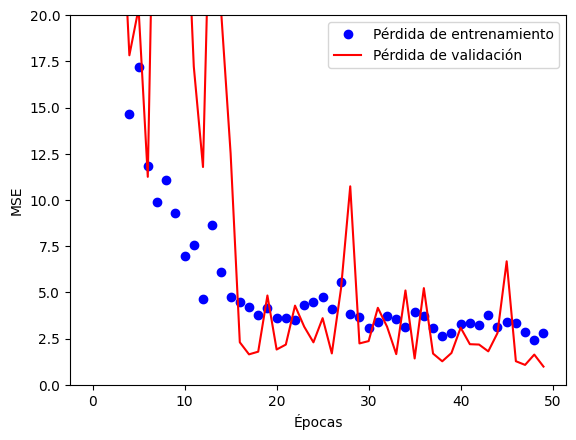

In [43]:
plot_epochs(history_final, 0, 20) # nor

In [44]:
model2.evaluate(X_test, y_test, verbose=1)
model2.evaluate(X_val, y_val, verbose=1)
model2.evaluate(X_train, y_train, verbose=1)

44/44 [==============================] - 1s 24ms/step - loss: 0.5671


0.5671336650848389

In [45]:
test_pred = model2.predict(X_test)
test_true = y_test
val_pred = model2.predict(X_val)
val_true = y_val
train_pred = model2.predict(X_train)
train_true = y_train

44/44 [==============================] - 1s 23ms/step


In [46]:
def plot_true_predicted(li, ls, steps):    # li -> limite inferior, ls -> limite superior en y!!!
    escala = 7
    marker = 5
    linea = np.arange(li,ls,steps)
    plt.figure(figsize=(escala, escala), dpi=90)
    
    plt.title("Datasets "+str(seleccion))
    plt.xlabel("Temperatura real (C°)")
    plt.ylabel("Temperatura estimada (C°)")
    plt.plot(train_true, train_pred,'b.',markersize=marker)
    plt.plot(val_true, val_pred, 'g.', markersize=marker)
    plt.plot(test_true, test_pred, 'r.', markersize=marker) 
    plt.plot(linea, linea, color='gray', linewidth = 2.5)
    
    
    plt.legend(['Datos de entrenamiento', 'Datos de validacion', 'Datos de prueba'], loc='upper left')

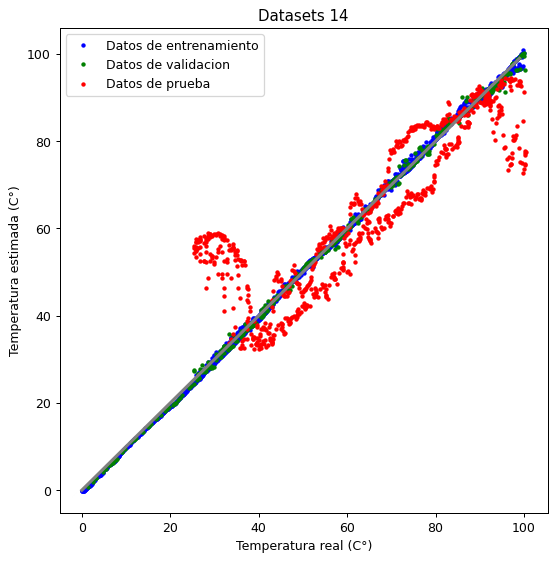

In [49]:
plot_true_predicted(0,100,1) # 1.7468

In [48]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import max_error as me
from sklearn.metrics import r2_score
import openpyxl

# Metrics for test data!
Modelo='Delta_Optuna_Rand_Rot180'
MSE = mse(test_true, test_pred)
MAE = mae(test_true, test_pred)
RMSE = np.sqrt(MSE)
max = me(test_true, test_pred)
r2 = r2_score(test_true, test_pred)

print("MSE: ", round(MSE, 2))
print("MAE: ", round(MAE, 2))
print("RMSE: ", round(RMSE, 2))
print("Maximun error: ", round(max, 2))
print("r2_score: ", r2)

MSE:  129.87
MAE:  8.18
RMSE:  11.4
Maximun error:  31.67
r2_score:  0.7259859442710876
